# Process-to-engineering simulator

This executed example follows the eight-step process-to-engineering workflow: process model, controlled cases, governing envelopes, discipline sizing, isolated hydraulic reruns, safety verification interfaces, process/design convergence, and a coordinated DEXPI 2.0 engineering package. It selects separator geometry, line diameter, compressor driver, safeguarding limits, an instrument range, a materials basis, and preliminary vessel wall thickness. All outputs remain review-required.

In [1]:
import os, sys, shutil
from pathlib import Path
ROOT = Path(os.environ.get('NEQSIM_PROJECT_ROOT', Path.cwd())).resolve()
while not (ROOT / 'pom.xml').exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'devtools'))
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_classes(neqsim_init(project_root=ROOT, recompile=not (ROOT / 'target/classes').exists(), verbose=False))
import jpype
JClass, JProxy = ns.JClass, jpype.JProxy
import pandas as pd
import matplotlib.pyplot as plt
print('Loaded process-to-engineering classes from', ROOT)

All NeqSim classes imported OK
Loaded process-to-engineering classes from /workspace/scratch/0f75633c511c/neqsim


## 1. Build the process model

The base process is intentionally given preliminary geometry. The engineering loop works on a copy and leaves these source values unchanged.

In [2]:
SystemSrkEos = JClass('neqsim.thermo.system.SystemSrkEos')
Stream = JClass('neqsim.process.equipment.stream.Stream')
Separator = JClass('neqsim.process.equipment.separator.Separator')
Compressor = JClass('neqsim.process.equipment.compressor.Compressor')
AdiabaticPipe = JClass('neqsim.process.equipment.pipeline.AdiabaticPipe')
ProcessSystem = JClass('neqsim.process.processmodel.ProcessSystem')
fluid = SystemSrkEos(300.0, 50.0)
for component, amount in [('methane', 0.92), ('ethane', 0.04), ('n-heptane', 0.04)]:
    fluid.addComponent(component, amount)
fluid.setMixingRule('classic')
feed = Stream('FEED', fluid); feed.setFlowRate(8000.0, 'kg/hr')
separator = Separator('INLET-SEP', feed)
compressor = Compressor('EXPORT-COMP', separator.getGasOutStream())
compressor.setOutletPressure(80.0, 'bara'); compressor.setPolytropicEfficiency(0.78)
export_line = AdiabaticPipe('EXPORT-LINE', compressor.getOutletStream())
export_line.setLength(1000.0); export_line.setDiameter(0.2027); export_line.setPipeWallRoughness(4.6e-5)
process = ProcessSystem()
for unit in [feed, separator, compressor, export_line]: process.add(unit)
process.run()
base_line_diameter = export_line.getDiameter()
print(f'Base process solved; preliminary export-line ID = {base_line_diameter:.4f} m')

Base process solved; preliminary export-line ID = 0.2027 m


## 2. Declare controlled cases and engineering modules

The callbacks only define process-case inputs. Every sizing result retains the governing case and the case-set result fingerprint.

In [3]:
NorsokBuilder = JClass('neqsim.process.engineering.NorsokOffshoreEngineeringBuilder')
DesignBuilder = JClass('neqsim.process.engineering.ProcessToEngineeringDesignBuilder')
DesignCase = JClass('neqsim.process.engineering.designcase.EngineeringDesignCase')
DesignCaseInput = JClass('neqsim.process.engineering.designcase.EngineeringDesignCase$Input')
Configurator = JClass('neqsim.process.engineering.designcase.EngineeringDesignCase$Configurator')
project = NorsokBuilder.from_('Notebook process-to-engineering design', process).projectId('pte-notebook').build()
def add_flow_case(case_id, flow, priority):
    def configure(case_process):
        case_process.getUnit('FEED').setFlowRate(flow, 'kg/hr')
    proxy = JProxy(Configurator, dict={'configure': configure})
    case = DesignCase(case_id, case_id, DesignCase.Type.CUSTOM, proxy).setPriority(priority)
    case.addInput(DesignCaseInput('feedFlow', flow, 'kg/hr', 'NOTEBOOK-DESIGN-BASIS'))
    project.addDesignCase(case)
add_flow_case('turndown', 5000.0, 5)
add_flow_case('normal', 8000.0, 10)
add_flow_case('maximum', 12000.0, 20)
drivers = jpype.JArray(jpype.JDouble)([500, 1000, 2000, 3000, 5000, 7500, 10000])
builder = DesignBuilder.on(project).exportLineLimits(25.0, 5.0).compressorDrivers(0.10, drivers)
builder.addInletCompressionExportSlice('INLET-SEP', 'EXPORT-COMP', 'EXPORT-LINE', '', 'PIT-100')
print('Configured cases:', project.getExecutableDesignCases().size(), 'modules:', project.getEngineeringDesignModules().size())

Configured cases: 3 modules: 7


## 3. Run to engineering convergence

A converged result means the declared calculations and constraints stabilized. It is not construction approval.

In [4]:
Simulator = JClass('neqsim.process.engineering.ProcessToEngineeringSimulator')
result = Simulator.run(project, 3)
loop = result.getEngineeringDesignLoopResult()
rows = []
for entry in loop.getState().getValues().entrySet():
    value = entry.getValue()
    rows.append({'design variable': str(entry.getKey()), 'value': value.getValue(), 'unit': str(value.getUnit())})
design_table = pd.DataFrame(rows).sort_values('design variable').reset_index(drop=True)
print('Converged:', loop.isConverged(), 'iterations:', loop.getIterations().size())
display(design_table)
assert loop.isConverged()
assert abs(process.getUnit('EXPORT-LINE').getDiameter() - base_line_diameter) < 1e-12

Converged: True iterations: 3


,design variable,value,unit
0,EXPORT-COMP.driverRatedPower,500.000000,kW
1,EXPORT-COMP.driverUtilization,0.361689,fraction
2,EXPORT-COMP.maximumActualInletFlow,0.072086,m3/s
3,EXPORT-LINE.designVelocity,1.584175,m/s
4,EXPORT-LINE.insideDiameter,0.202700,m
5,EXPORT-LINE.predictedPressureGradient,0.048304,bar/km
6,INLET-SEP.blowdownTargetPressure,6.900000,bara
7,INLET-SEP.corrosionAllowance,3.000000,mm
8,INLET-SEP.designLife,25.000000,year
9,INLET-SEP.designPressure,55.000000,bara


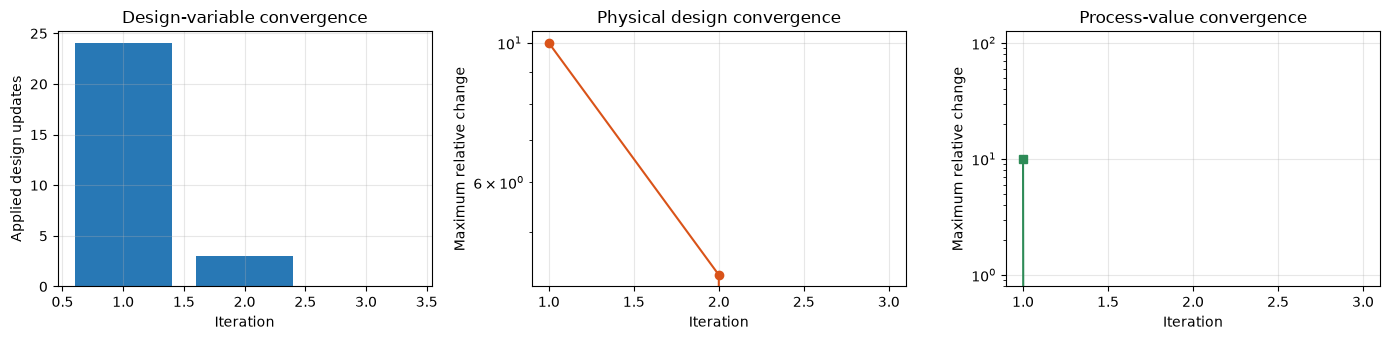

In [5]:
iteration_numbers = [item.getNumber() for item in loop.getIterations()]
updates = [item.getAppliedUpdateCount() for item in loop.getIterations()]
changes = [item.getMaximumRelativeChange() for item in loop.getIterations()]
process_changes = [item.getConvergenceReport().getMaximumProcessValueRelativeChange() for item in loop.getIterations()]
finite_changes = [min(value, 10.0) for value in changes]
finite_process_changes = [min(value, 10.0) for value in process_changes]
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
axes[0].bar(iteration_numbers, updates, color='#2878B5'); axes[0].set(xlabel='Iteration', ylabel='Applied design updates', title='Design-variable convergence')
axes[1].semilogy(iteration_numbers, finite_changes, marker='o', color='#D95319'); axes[1].set(xlabel='Iteration', ylabel='Maximum relative change', title='Physical design convergence')
axes[2].semilogy(iteration_numbers, finite_process_changes, marker='s', color='#2E8B57'); axes[2].set(xlabel='Iteration', ylabel='Maximum relative change', title='Process-value convergence')
for ax in axes: ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

The first iteration applies continuous calculations and discrete candidates. A following hydraulic pass measures the process response, and the final iteration proves that both physical design variables and process values are stable. Initial infinite changes are clipped only for plotting.

## 4. Compile the designed process to the governed DEXPI package

In [6]:
Compiler = JClass('neqsim.process.engineering.deliverables.EngineeringDeliverableCompiler')
Paths = JClass('java.nio.file.Paths')
package_dir = Path('/tmp/neqsim-process-to-engineering-package')
shutil.rmtree(package_dir, ignore_errors=True)
compiled = Compiler.compile(project, Paths.get(str(package_dir)))
artifacts = sorted(path.name for path in package_dir.iterdir())
print('Package valid:', compiled.getValidationReport().isValid())
print('DEXPI 2.0:', compiled.getDexpiResult().getDexpi20File())
print('Generated top-level artifacts:', len(artifacts))
assert compiled.getValidationReport().isValid()
assert (package_dir / 'plant.dexpi.xml').exists()
assert (package_dir / 'engineering-calculations.json').exists()
assert (package_dir / 'engineering-diagram-layout.json').exists()
assert (package_dir / 'equipment-datasheets.json').exists()
assert (package_dir / 'io-list.json').exists()
assert (package_dir / 'alarm-trip-schedule.json').exists()
assert (package_dir / 'psv-datasheets.json').exists()
assert (package_dir / 'utility-summary.json').exists()
assert (package_dir / 'materials-selection-report.json').exists()
assert (package_dir / 'unresolved-engineering-actions.json').exists()

Package valid: True
DEXPI 2.0: /tmp/neqsim-process-to-engineering-package/plant.dexpi.xml
Generated top-level artifacts: 40


The package uses the isolated designed geometry and carries calculated values into the canonical graph, DEXPI references, registers, and calculation evidence. HAZOP/LOPA, SIL approval, vendor guarantees, final code design, materials approval, and construction authorization remain accountable engineering activities.